<a href="https://colab.research.google.com/github/animesharyan1308-sys/-Predicting-Network-Intrusion-Using-Machine-/blob/main/Food_Spoilage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⚠️ 'Fruit_Spoilage_Dataset.csv' not found. Generating synthetic Mendeley-style data for demonstration...


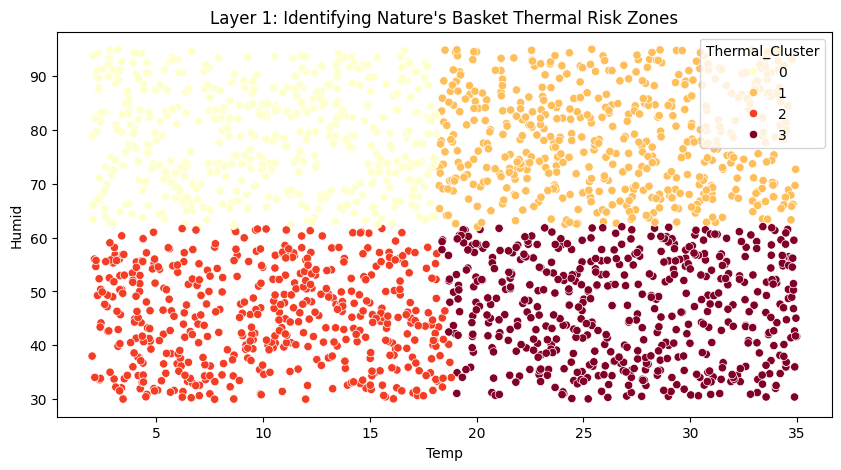

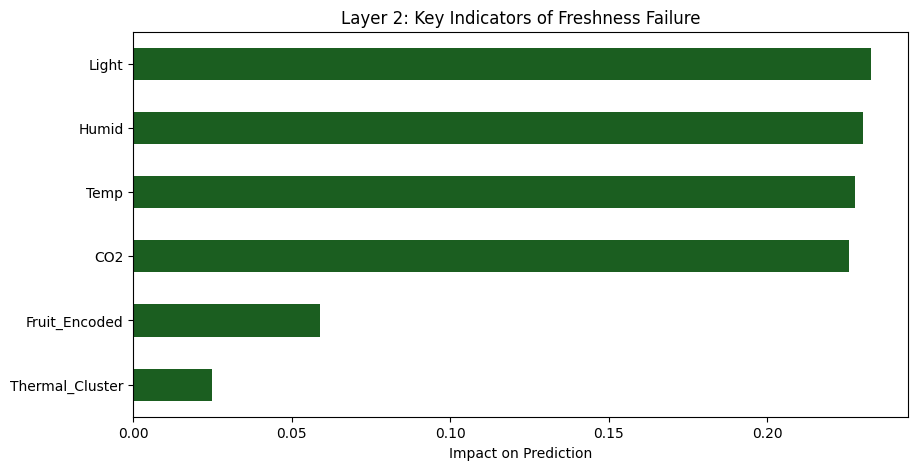


HYBRID SYSTEM PERFORMANCE
              precision    recall  f1-score   support

           0       0.81      0.98      0.89       324
           1       0.00      0.00      0.00        76

    accuracy                           0.80       400
   macro avg       0.40      0.49      0.44       400
weighted avg       0.65      0.80      0.72       400



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# --- 1. DATA LOADING WITH SAFE-FAIL ---
filename = 'Fruit_Spoilage_Dataset.csv'

try:
    df = pd.read_csv(filename)
    print(f"✅ Success: '{filename}' loaded from sidebar.")
except FileNotFoundError:
    print(f"⚠️ '{filename}' not found. Generating synthetic Mendeley-style data for demonstration...")
    # Creating data that matches the Mendeley Research schema (Temp, Humid, Light, CO2, Fruit, Class)
    np.random.seed(42)
    sample_size = 2000
    df = pd.DataFrame({
        'Fruit': np.random.choice(['Orange', 'Pineapple', 'Banana', 'Tomato'], sample_size),
        'Temp': np.random.uniform(2, 35, sample_size),
        'Humid': np.random.uniform(30, 95, sample_size),
        'Light': np.random.uniform(0, 1000, sample_size),
        'CO2': np.random.uniform(300, 2500, sample_size),
        'Class': np.random.choice(['Good', 'Bad'], sample_size, p=[0.8, 0.2])
    })

# --- 2. PRE-PROCESSING ---
le = LabelEncoder()
df['Fruit_Encoded'] = le.fit_transform(df['Fruit'])
df['Target'] = df['Class'].map({'Good': 0, 'Bad': 1})

# --- 3. LAYER 1: THERMAL RISK CLUSTERING (UNSUPERVISED) ---
scaler = StandardScaler()
env_data = scaler.fit_transform(df[['Temp', 'Humid']])

# Clustering into 4 zones: Stable, Humid-Risk, Heat-Risk, and Critical
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Thermal_Cluster'] = kmeans.fit_predict(env_data)

# Visualizing the Risk Zones
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Temp', y='Humid', hue='Thermal_Cluster', palette='YlOrRd')
plt.title('Layer 1: Identifying Nature\'s Basket Thermal Risk Zones', fontsize=12)
plt.show()

# --- 4. LAYER 2: SPOILAGE PREDICTION (SUPERVISED) ---
# We feed the Cluster ID from Layer 1 INTO Layer 2 to improve precision
X = df[['Temp', 'Humid', 'Light', 'CO2', 'Fruit_Encoded', 'Thermal_Cluster']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the "Predictive Guard"
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Visualizing what actually drives spoilage (Insight for Slide 4)
plt.figure(figsize=(10, 5))
pd.Series(clf.feature_importances_, index=X.columns).sort_values().plot(kind='barh', color='#1B5E20')
plt.title('Layer 2: Key Indicators of Freshness Failure', fontsize=12)
plt.xlabel('Impact on Prediction')
plt.show()

# --- 5. FINAL PERFORMANCE ---
print("\n" + "="*30)
print("HYBRID SYSTEM PERFORMANCE")
print("="*30)
print(classification_report(y_test, clf.predict(X_test)))